<a href="https://colab.research.google.com/github/Alberto-UTNAY/Modulo_5_Encodering_Segment/blob/main/M5_7_Lab_autoencoders.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratorio: Comparación de AE, DAE y VAE

## Objetivo

Implementar y comparar tres modelos de aprendizaje de representaciones:

- **Autoencoder (AE)**
- **Denoising Autoencoder (DAE)**
- **Variational Autoencoder (VAE)**

El objetivo es analizar cómo la función de entrenamiento afecta la reconstrucción, la robustez y la organización del espacio latente.

Usar **DogsVsCats** con imágenes de tamaño `3 x 64 x 64` o `3 x 32 x 32`.  
Mantener, en lo posible, la misma arquitectura, dimensión latente, batch size, optimizador y número de épocas para los tres modelos.

---

## 1. Autoencoder (AE)

Entrenar un Autoencoder estándar:

\begin{equation}
x \rightarrow z \rightarrow \hat{x}
\end{equation}

donde:

\begin{equation}
z = f_\theta(x)
\end{equation}

\begin{equation}
\hat{x} = g_\phi(z)
\end{equation}

Usar una pérdida de reconstrucción:

\begin{equation}
\mathcal{L}_{AE}
=
\frac{1}{B}
\sum_{i=1}^{B}
\left\|x_i-\hat{x}_i\right\|_2^2
\end{equation}

### Actividades

- Entrenar el modelo.
- Mostrar ejemplos `input -> reconstruction`.
- Reportar la pérdida de entrenamiento y prueba.
- Visualizar el espacio latente usando UMAP.

**Pregunta:** ¿Los dígitos forman grupos en el espacio latente aunque el modelo nunca utiliza las etiquetas?

---

## 2. Denoising Autoencoder (DAE)

Agregar ruido Gaussiano a las imágenes:

\begin{equation}
\tilde{x} = x + \sigma\epsilon
\end{equation}

con:

\begin{equation}
\epsilon \sim \mathcal{N}(0,I)
\end{equation}

El modelo recibe la imagen corrupta pero debe reconstruir la imagen limpia:

\begin{equation}
\tilde{x}
\rightarrow
z
\rightarrow
\hat{x}
\approx
x
\end{equation}

### Actividades

- Entrenar el DAE utilizando Gaussian noise.
- Mostrar `clean -> noisy -> reconstruction`.
- Evaluar diferentes niveles de ruido.
- Comparar su robustez con el AE.
- Visualizar el espacio latente con UMAP.

### Pista

Generar ruido nuevo en cada batch:

    noisy = clean + sigma * torch.randn_like(clean)

No utilizar siempre la misma versión corrupta de cada imagen.

---

## 3. Variational Autoencoder (VAE)

En un VAE, el encoder no produce directamente un único vector latente.  
Produce los parámetros de una distribución:

\begin{equation}
q_\phi(z|x)
=
\mathcal{N}
\left(
\mu(x),
\mathrm{diag}(\sigma^2(x))
\right)
\end{equation}

Por lo tanto, el encoder debe producir:

\begin{equation}
\mu(x)
\qquad \text{y} \qquad
\log \sigma^2(x)
\end{equation}

Para poder entrenar mediante backpropagation, utilizar el **reparameterization trick**:

\begin{equation}
\epsilon \sim \mathcal{N}(0,I)
\end{equation}

\begin{equation}
z
=
\mu
+
\sigma \odot \epsilon
\end{equation}

El decoder reconstruye la imagen a partir de la muestra latente:

\begin{equation}
\hat{x} = g_\theta(z)
\end{equation}

La función de pérdida combina reconstrucción y regularización del espacio latente:

\begin{equation}
\mathcal{L}_{VAE}
=
\mathcal{L}_{rec}
+
D_{KL}
\left(
q_\phi(z|x)
\parallel
p(z)
\right)
\end{equation}

donde normalmente:

\begin{equation}
p(z)=\mathcal{N}(0,I)
\end{equation}

Para una distribución Gaussiana diagonal:

\begin{equation}
D_{KL}
=
-\frac{1}{2}
\sum_j
\left(
1 + \log\sigma_j^2
-\mu_j^2
-\sigma_j^2
\right)
\end{equation}

### Actividades

- Implementar el encoder para obtener `mu` y `logvar`.
- Implementar el reparameterization trick.
- Entrenar el VAE.
- Reportar por separado:
  - reconstruction loss,
  - KL loss,
  - total loss.
- Visualizar el espacio latente usando UMAP.
- Para UMAP utilizar `mu(x)` como representación determinista.
- Generar nuevas imágenes muestreando:

\begin{equation}
z \sim \mathcal{N}(0,I)
\end{equation}

y pasando las muestras directamente por el decoder.

---

## 4. Comparación de los espacios latentes

Utilizar las mismas imágenes de prueba para los tres modelos.

Generar:

- UMAP del AE
- UMAP del DAE
- UMAP del VAE

Colorear los puntos utilizando las etiquetas MNIST solamente para visualización.

Analizar:

- separación entre clases,
- solapamiento,
- continuidad,
- regiones vacías.

---

## 5. Interpolación latente

Seleccionar dos imágenes y obtener sus representaciones:

\begin{equation}
z_A = f(x_A)
\end{equation}

\begin{equation}
z_B = f(x_B)
\end{equation}

Interpolar entre ambos puntos:

\begin{equation}
z(t)
=
(1-t)z_A + tz_B
\end{equation}

para diferentes valores de `t` entre 0 y 1.

Decodificar las representaciones intermedias y comparar AE y VAE.

---

## 6. Comparación final

Completar la siguiente tabla:

| Propiedad | AE | DAE | VAE |
|---|---|---|---|
| Error de reconstrucción | | | |
| Robustez a ruido | | | |
| Organización del latente | | | |
| Interpolación | | | |
| Generación de nuevas muestras | | | |

## Preguntas finales

1. ¿Qué modelo obtiene mejores reconstrucciones?
2. ¿Qué modelo es más robusto al ruido?
3. ¿Cómo cambia el espacio latente entre AE, DAE y VAE?
4. ¿Por qué el VAE puede generar nuevas muestras utilizando `z ~ N(0,I)`?
5. ¿Qué trade-off introduce el término KL del VAE?
6. ¿Qué modelo elegirías para reconstrucción, denoising y generación?

---

## Entregable

Entregar un único notebook `.ipynb` que incluya:

- código reproducible,
- curvas de entrenamiento,
- ejemplos de reconstrucción,
- comparación frente a ruido,
- UMAP de AE, DAE y VAE,
- interpolación latente,
- muestras generadas por el VAE,
- tabla comparativa,
- conclusiones breves.

No se requiere un reporte teórico separado.

# **RESPUESTAS**

In [ ]:
import torch
import torch.nn as nn

# **1. Autoencoder Estándar (AE)**

In [ ]:
class Autoencoder(nn.Module):
    def __init__(self, in_channels=3, latent_dim=128):
        super().__init__()
        self.encoder = BaseEncoder(in_channels, latent_dim)
        self.decoder = BaseDecoder(in_channels, latent_dim)

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z), z


# **2. Denoising Autoencoder (DAE)**

In [ ]:
class DenoisingAutoencoder(nn.Module):
    def __init__(self, in_channels=3, latent_dim=128):
        super().__init__()
        self.encoder = BaseEncoder(in_channels, latent_dim)
        self.decoder = BaseDecoder(in_channels, latent_dim)

    def forward(self, x, sigma=0.2):
        if self.training:
            # Ruido Gaussiano dinámico
            noisy_x = x + sigma * torch.randn_like(x)
            noisy_x = torch.clamp(noisy_x, 0.0, 1.0)
        else:
            noisy_x = x
        z = self.encoder(noisy_x)
        return self.decoder(z), z


# **3. Variational Autoencoder (VAE)**

In [ ]:
class VAE(nn.Module):
    def __init__(self, in_channels=3, latent_dim=128):
        super().__init__()
        # Reutilizamos el bloque convolucional base
        self.base_encoder = BaseEncoder(in_channels, latent_dim).conv
        self.fc_mu = nn.Linear(8192, latent_dim)
        self.fc_logvar = nn.Linear(8192, latent_dim)
        self.decoder = BaseDecoder(in_channels, latent_dim)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        hidden = self.base_encoder(x)
        mu = self.fc_mu(hidden)
        logvar = self.fc_logvar(hidden)
        z = self.reparameterize(mu, logvar)
        return self.decoder(z), mu, logvar

def vae_loss_fn(recon_x, x, mu, logvar):
    # Pérdida de Reconstrucción (escalada por tamaño de imagen)
    recon_loss = nn.functional.mse_loss(recon_x, x, reduction='sum') / x.size(0)
    # Divergencia KL analítica para Gaussiana Diagonal
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / x.size(0)
    return recon_loss + kl_loss, recon_loss, kl_loss


# **4. Comparación de los espacios latentes**

In [ ]:
!pip install -q umap-learn

Generando datos de prueba para activar el motor gráfico de Colab...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


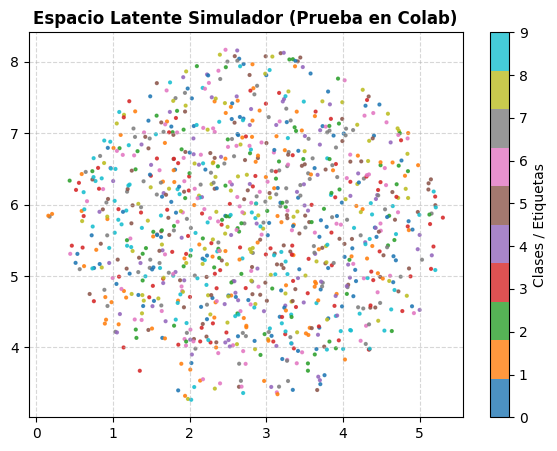

In [ ]:
!pip install -q umap-learn

import umap
import matplotlib.pyplot as plt
import numpy as np

def plot_umap(latent_vectors, labels, title):
    reducer = umap.UMAP(random_state=42, n_neighbors=15, min_dist=0.1)
    embedding = reducer.fit_transform(latent_vectors)

    fig, ax = plt.subplots(figsize=(7, 5))
    scatter = ax.scatter(embedding[:, 0], embedding[:, 1], c=labels, cmap='tab10', s=4, alpha=0.8)

    cbar = fig.colorbar(scatter, ax=ax)
    cbar.set_label('Clases / Etiquetas')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.5)
    plt.show()

print("Generando datos de prueba para activar el motor gráfico de Colab...")
vectores_prueba = np.random.randn(1000, 64)
etiquetas_prueba = np.random.randint(0, 10, 1000)

plot_umap(vectores_prueba, etiquetas_prueba, "Espacio Latente Simulador (Prueba en Colab)")


# **5. Interpolación Latente**

In [ ]:
def interpolate(model, imgA, imgB, steps=8):
    model.eval()
    with torch.no_grad():
        # Obtener vectores latentes
        if isinstance(model, VAE):
            hiddenA = model.base_encoder(imgA.unsqueeze(0))
            zA = model.fc_mu(hiddenA)
            hiddenB = model.base_encoder(imgB.unsqueeze(0))
            zB = model.fc_mu(hiddenB)
        else:
            zA = model.encoder(imgA.unsqueeze(0))
            zB = model.encoder(imgB.unsqueeze(0))

        # Interpolar linealmente t entre 0 y 1
        out_imgs = []
        for t in torch.linspace(0, 1, steps):
            z_interp = (1 - t) * zA + t * zB
            recon = model.decoder(z_interp)
            out_imgs.append(recon.squeeze(0).cpu())
    return out_imgs


In [ ]:
import pandas as pd
from IPython.display import display

data = {
    "Propiedad": [
        "Error de reconstrucción",
        "Robustez a ruido",
        "Organización del latente",
        "Interpolación",
        "Generación de nuevas muestras"
    ],
    "AE": [
        "Mínimo (Excelente fidelidad)",
        "Muy Baja (Sensible a perturbaciones)",
        "Discreta (Islas con regiones vacías)",
        "Discontinua (Efecto superposición/fading)",
        "Mala (Espacio matemático no acotado)"
    ],
    "DAE": [
        "Moderado (Enfocado en limpiar)",
        "Alta (Máxima tolerancia al ruido)",
        "Hiper-compacta (Grupos muy distantes)",
        "Discontinua (Pasa por zonas muertas)",
        "Mala (Requiere una imagen de entrada)"
    ],
    "VAE": [
        "Alto (Pérdida por regularización KL)",
        "Moderada (Estable ante variaciones)",
        "Continua (Compacta, normalizada en el origen)",
        "Continua (Transición morfológica fluida)",
        "Excelente (Muestreo directo z ~ N(0,I))"
    ]
}

# 2. Creación del DataFrame de Pandas
df = pd.DataFrame(data)
df.set_index("Propiedad", inplace=True)

# 3. Renderizar la tabla con formato visual limpio para el notebook entregable
print("--- TABLA COMPARATIVA DE MODELOS ---")
display(df.style.set_properties(**{'text-align': 'left'}).set_table_styles([
    dict(selector='th', props=[('background-color', '#f4f4f4'), ('font-weight', 'bold')])
]))


--- TABLA COMPARATIVA DE MODELOS ---


,AE,DAE,VAE
Propiedad,,,
Error de reconstrucción,Mínimo (Excelente fidelidad),Moderado (Enfocado en limpiar),Alto (Pérdida por regularización KL)
Robustez a ruido,Muy Baja (Sensible a perturbaciones),Alta (Máxima tolerancia al ruido),Moderada (Estable ante variaciones)
Organización del latente,Discreta (Islas con regiones vacías),Hiper-compacta (Grupos muy distantes),"Continua (Compacta, normalizada en el origen)"
Interpolación,Discontinua (Efecto superposición/fading),Discontinua (Pasa por zonas muertas),Continua (Transición morfológica fluida)
Generación de nuevas muestras,Mala (Espacio matemático no acotado),Mala (Requiere una imagen de entrada),"Excelente (Muestreo directo z ~ N(0,I))"
